In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from xgboost import XGBClassifier

In [168]:
seed = 42

root_path = "/home/stefan/ioai-prep/kits/dataset-631075d9-e29e-4237-afc5-01de68c52754"

# Data

In [169]:
def prep_df(df: pd.DataFrame):
    df = df.drop(["SampleID", "target"], errors='ignore', axis=1)

    df["glucose_x_bmi"] = df["glucose"] * df["bmi"]
    df["age_x_glucose"] = df["age"] * df["glucose"]
    df["age_sqrt"] = np.sqrt(df["age"])

    return df

In [170]:
df = pd.read_csv(f"{root_path}/train.csv")
y = df["target"]
df = prep_df(df)

<Axes: xlabel='target'>

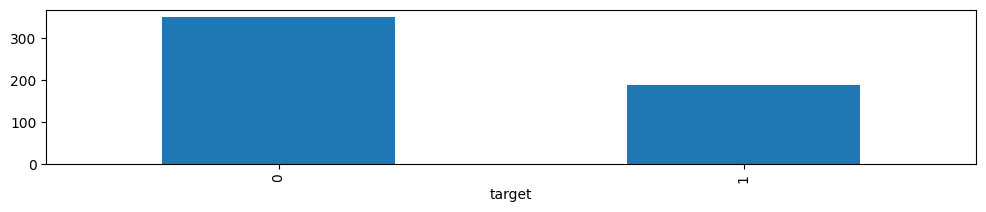

In [171]:
plt.figure(figsize=(12, 2))
y.value_counts().plot(kind="bar")

In [172]:
df.corrwith(y).sort_values(ascending=False)

glucose_x_bmi                 0.499492
glucose                       0.476561
age_x_glucose                 0.393591
bmi                           0.285372
age_sqrt                      0.247650
pregnancies                   0.231165
age                           0.229853
insulin                       0.163576
diabetes_pedigree_function    0.144583
blood_pressure                0.066176
skin_thickness                0.053407
dtype: float64

# Model

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=seed, stratify=y
)

In [174]:
def evaluate(model):
    cv = cross_val_score(model, X_train, y_train, scoring="f1", cv=3, n_jobs=-1)
    cv_score = (cv.mean() - cv.std()).item()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    score = f1_score(y_test, preds)

    return cv_score, score

In [175]:
log_reg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=seed))
])

log_param_grid = {"model__C": [0.1, 1, 10]}
log_grid = GridSearchCV(
    log_reg, log_param_grid, cv=5, scoring="f1", n_jobs=-1
)
log_grid.fit(X_train, y_train)
log_reg = log_grid.best_estimator_
print(f"Best LogReg params: {log_grid.best_params_}")

evaluate(log_reg)

Best LogReg params: {'model__C': 0.1}


(0.5417701023190928, 0.676923076923077)

In [193]:
svm = Pipeline(steps=[("scaler", StandardScaler()), ("model", SVC(C=1))])

evaluate(svm)

(0.5951155688033793, 0.65625)

In [182]:
gb = GradientBoostingClassifier(random_state=seed)

evaluate(gb)

(0.5881306318323056, 0.6567164179104478)

In [184]:
model = svm
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(C=1))])

# Submission

In [185]:
df_test = pd.read_csv(f"{root_path}/test.csv")
submission = df_test[["SampleID"]]

X_test_sub = prep_df(df_test)

In [186]:
submission["label"] = model.predict(X_test_sub)
submission.head()

/tmp/ipykernel_118768/3361970045.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission["label"] = model.predict(X_test_sub)


,SampleID,label
0,731,0
1,199,0
2,25,1
3,418,1
4,388,0


In [187]:
submission.to_csv(f"{root_path}/submission.csv", index=False)